In [1]:
# =============================================================================
# Rim elevation reconstruction -- multi-network entry point
# -----------------------------------------------------------------------------
# Single, city-parameterised notebook (replacing the former per-city files):
# it detects and corrects anomalous recorded rim (surface) elevations and
# predicts missing ones using the local spatial interpolation framework
# (IDW, linear regression, quadratic regression; manuscript Section 2.3).
# Two evaluation settings are run: a controlled injected-anomaly experiment
# and a real-data comparison against an external LiDAR reference
# (Section 2.3.6). The retained configuration is then applied to the full
# dataset and the corrected/completed rim elevation is merged back into the
# pipe and node tables for the downstream invert-elevation notebook.
#
# The network is selected via the `choice` variable in the next cell; all
# reconstruction logic lives in the shared `function.py` module, imported
# below.
# =============================================================================
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
import matplotlib.colors as mcolors
import glob
import rasterio
import contextily as ctx
from joblib import Parallel, delayed
import function
import importlib

importlib.reload(function)

from function import *

In [2]:
# ── Network selection ──────────────────────────────────────────────────────
# Set `choice` to one of: "montpellier", "angers", "kapiti", "auckland".
# Each branch loads that network's preprocessed pipe/node tables and sets the
# projected CRS (`epsg`), the injected-anomaly amplitude upper bound
# (`err_max`, calibrated to the network's elevation range), the output name
# stem (`network`), and the LiDAR tile glob (`lidar`).
choice = "kapiti"

if choice == "angers":
    #Angers
    network = "Angers"
    epsg = "EPSG:2154"
    err_max = 80
    lidar = "../lidar_ref/lidar_angers/*.tif"

elif choice == "kapiti":
    #Kapiti Coast
    network = "Kapiti"
    epsg = "EPSG:2193"
    err_max = 90
    lidar = "../lidar_ref/lidar_kapiti/*.tif"

elif choice == "auckland":
    #Auckland
    network = "Auckland"
    epsg = "EPSG:2193"
    err_max = 100
    lidar = "../lidar_ref/lidar_auckland/*.tif"

elif choice == "montpellier":
    #Montpellier
    network = "Montpellier"
    epsg = "EPSG:2154"
    err_max = 120
    lidar = "../lidar_ref/lidar_montpellier/*.tif"

df_pipe = pd.read_pickle(f"../data/{network}/df_pipe_{network}.pkl")
df_node = pd.read_pickle(f"../data/{network}/df_node_{network}.pkl")



In [3]:
# Minimal working table for rim-elevation reconstruction: node identifier,
# projected coordinates, and the elevation attribute (rim elevation).

df_elev = df_node[["node_id", "x", "y", "rimElevation"]]

print(df_elev["rimElevation"].describe())
rimElev = np.array(df_elev["rimElevation"].dropna())

print("99 percentile =", np.quantile(rimElev, 0.99))

count    6338.000000
mean       12.733528
std        15.616154
min         0.970000
25%         4.570000
50%         7.080000
75%        12.717500
max       127.030000
Name: rimElevation, dtype: float64
99 percentile = 80.16230000000002


In [4]:
# Manual single-configuration test: pick any hyperparameter combination by
# hand (here radius=250 m, node_min=10, linear regression (LR), inverse weighting,
# 10% injected anomalies (pourcent = 0.1) to quickly try it out independently of the
# systematic grid search below. Intermediate evaluation is reported at the
# 10 m and 5 m thresholds. Output is displayed, not stored.

modelWithInjectedErrors(df_elev, 250, 10, "LR", "inverse", seuil_clean = 5, thresholds = [40, 25, 15, 10, 5],
                            inter_threshold = [10,5], err_min = 0, err_max = err_max, pourcent = 0.1)

Anomalous nodes identified and removed:  266
Anomalous nodes identified:  275
Anomalous nodes corrected:  275
Anomalous nodes identified:  136
Anomalous nodes corrected:  136
Anomalous nodes identified:  82
Anomalous nodes corrected:  82
Anomalous nodes identified:  36
Anomalous nodes corrected:  35
Corrected nodes  : 525
Missing nodes remaining : 0
Missing nodes reconstructed : 0
Percentage of missing nodes reconstructed : nan%

Threshold =  10
Radius =  250
Min. neighbours required for a correction =  10
Injected errors range :  0  -  90
Model :  LR
── Distribution of the corrections ──
  Mean delta  : 44.2m
  Median delta: 44.0m
  Max delta   : 86.0m
 Median number of neighbours : 37.0

── Ten largest corrections ──
        node_id  original  corrected  delta  n_voisins
47   KWWN001940      89.0       3.01  85.99         13
189  KWWN004384      87.0       3.62  83.38         17
201  KWWN005584      87.0       4.60  82.40         32
144  KWWN003341      88.0       5.65  82.35        

C:\Users\sebas\Documents\Waterwaste\Code\function.py:576: RuntimeWarning: invalid value encountered in scalar divide
  print(f"Percentage of missing nodes reconstructed : {n_nan_corrected / (n_nan_remaining + n_nan_corrected):.2%}")
C:\Users\sebas\Documents\Waterwaste\Code\function.py:744: RuntimeWarning: invalid value encountered in scalar divide
  "pct_nan_corrected": float(n_nan_corrected / (n_nan_remaining + n_nan_corrected)),


Anomalous nodes identified:  112
Anomalous nodes corrected:  108
Corrected nodes  : 623
Missing nodes remaining : 0
Missing nodes reconstructed : 0
Percentage of missing nodes reconstructed : nan%

Threshold =  5
Radius =  250
Min. neighbours required for a correction =  10
Injected errors range :  0  -  90
Model :  LR
── Distribution of the corrections ──
  Mean delta  : 37.6m
  Median delta: 36.1m
  Max delta   : 86.0m
 Median number of neighbours : 37.0

── Ten largest corrections ──
        node_id  original  corrected  delta  n_voisins
47   KWWN001940      89.0       3.01  85.99         13
189  KWWN004384      87.0       3.62  83.38         17
201  KWWN005584      87.0       4.60  82.40         32
144  KWWN003341      88.0       5.65  82.35         57
64   KWWN001852      86.0       3.78  82.22         24
56   KWWN001882      85.0       2.96  82.04         35
25   KWWN000910      87.0       5.31  81.69         25
196  KWWN005107      88.0       6.62  81.38         44
91   KWWN0020

C:\Users\sebas\Documents\Waterwaste\Code\function.py:576: RuntimeWarning: invalid value encountered in scalar divide
  print(f"Percentage of missing nodes reconstructed : {n_nan_corrected / (n_nan_remaining + n_nan_corrected):.2%}")
C:\Users\sebas\Documents\Waterwaste\Code\function.py:744: RuntimeWarning: invalid value encountered in scalar divide
  "pct_nan_corrected": float(n_nan_corrected / (n_nan_remaining + n_nan_corrected)),


[{'method': 'LR',
  'radius': 250,
  'seuil': 10,
  'node_min': 10,
  'weight_method': 'inverse',
  'err_min': 0,
  'err_max': 90,
  'pct_error': 0.1,
  'feature': 'rimElevation',
  'restriRim': False,
  'restriInvert': False,
  'depth_min': 0,
  'depth_max': 0,
  'depth_median': 0,
  'slope_min': 0,
  'slope_max': 0,
  'slope_median': 0,
  'alpha': 0,
  'n_aberrants_detected': 525,
  'n_corrected': 525,
  'n_nan_remaining': 0,
  'n_nan_corrected': 0,
  'pct_nan_corrected': nan,
  'precision': 0.9733333333333334,
  'recall': 0.8404605263157895,
  'f1': 0.9020300088261254,
  'matthews_corrcoef': 0.8949313254793486,
  'precision_rim_restr': 0.9733333333333334,
  'recall_rim_restr': 0.8404605263157895,
  'f1_rim_restr': 0.9020300088261254,
  'matthews_corrcoef_rim_restr': 0.8949313254793486,
  'precision_inv_restr': 0.9733333333333334,
  'recall_inv_restr': 0.8404605263157895,
  'f1_inv_restr': 0.9020300088261254,
  'matthews_corrcoef_inv_restr': 0.8949313254793486,
  'precision_neighbors

In [6]:
# ── Injected-anomaly grid search: hyperparameter exploration ───────────────
# Sweep the hyperparameter grid of Section 2.3.6 (interpolation method,
# search radius, minimum neighbour count, weighting scheme, injected-anomaly
# rate). Quadratic regression (QR) needs at least 6 neighbours to fit its 6
# coefficients, so node_min=3 is skipped for it; IDW carries its own inverse
# weighting and is therefore only run with the "inverse" scheme. `run_one_injected`
# wraps each configuration in try/except so one failing fit does not abort
# the whole parallel sweep.
def run_one_injected(pct, method, radius, node_min, weight,
            inter_threshold, df_elev):
    """Run modelWithInjectedErrors for one hyperparameter configuration and
    return its list of per-threshold evaluation summaries (empty on failure)."""
    results = []
    try:
        result = modelWithInjectedErrors(df_elev, radius, node_min, method, weight, seuil_clean = 5, thresholds = thresholds,
                                inter_threshold = inter_threshold, err_min = 0, err_max = err_max, pourcent = pct, verbose = False
                               )
        for res in result:
            results.append(res)
    except Exception as e:
        print(f"ERREUR : pct={pct} method={method} radius={radius} "
              f"node_min={node_min} weight={weight} → {e}")
    return results

methods = ["IDW","LR", "QR"]
radii = [80, 150, 250, 400]
inter_threshold = [3, 5, 10]
node_mins = [3, 6, 10, 15, 20]
weights = ["normal", "inverse", "inverseSquared"]
thresholds = [40, 25, 15, 10, 5, 3]
pourcent = [0.01, 0.05, 0.1, 0.2, 0.3, 0.5, 0.8]

jobs = []
for pct in pourcent:
    for method in methods:
        node_mins_iter = node_mins[1:] if method == "QR" else node_mins
        weights_iter   = ["inverse"] if method == "IDW" else weights

        for radius in radii:
            for node_min in node_mins_iter:
                for weight in weights_iter:
                    jobs.append((pct, method, radius, node_min, weight))

print(f"Number of jobs: {len(jobs)}")

Number of jobs: 896


In [7]:
# ── Full run ─────────────────────────────────────
# n_jobs: number of CPU cores to use in parallel -- adjust to your machine
# (e.g. n_jobs=-1 uses all available cores).
all_results = Parallel(n_jobs=16, verbose=10)(
    delayed(run_one_injected)(pct, method, radius, node_min, weight,
                     inter_threshold, df_elev)
    for pct, method, radius, node_min, weight in jobs
)

# ── Flatten and save ──────────────────────────────
results = [r for sublist in all_results for r in sublist]
df_results = pd.DataFrame(results)
df_results.to_csv(f"Rim{network}ReconstructionErrors_XXXXXXXX.csv", index=False) # NOTE: replace XXXXXXXX with the run date before executing
print(f"Saved: {len(df_results)} rows")

[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done   9 tasks      | elapsed:    8.8s
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    9.8s
[Parallel(n_jobs=16)]: Done  29 tasks      | elapsed:   10.9s
[Parallel(n_jobs=16)]: Done  40 tasks      | elapsed:   15.6s
[Parallel(n_jobs=16)]: Done  53 tasks      | elapsed:   22.7s
[Parallel(n_jobs=16)]: Done  66 tasks      | elapsed:   26.4s
[Parallel(n_jobs=16)]: Done  81 tasks      | elapsed:   31.7s
[Parallel(n_jobs=16)]: Done  96 tasks      | elapsed:   36.6s
[Parallel(n_jobs=16)]: Done 113 tasks      | elapsed:   47.2s
[Parallel(n_jobs=16)]: Done 130 tasks      | elapsed:   55.1s
[Parallel(n_jobs=16)]: Done 149 tasks      | elapsed:   59.8s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:  1.1min
[Parallel(n_jobs=16)]: Done 189 tasks      | elapsed:  1.3min
[Parallel(n_jobs=16)]: Done 210 tasks      | elapsed:  1.4min
[Parallel(n_jobs=16)]: Done 233 tasks      | elapsed:  

Saved: 2394 rows


[Parallel(n_jobs=16)]: Done 896 out of 896 | elapsed:  7.6min finished


In [8]:
# ── External reference: LiDAR baseline (before reconstruction) ─────────────
# Sample every LiDAR tile at each node location (per-tile bounding-box test +
# rasterio.sample, which scales from a single city to a whole region) to
# build the independent ground-truth elevation `z_ref`. The error of the
# raw, uncorrected rim elevations against this reference is reported as the
# baseline that the reconstruction is later compared to.
tif_files = glob.glob(lidar)

gdf_before = gpd.GeoDataFrame(df_elev, geometry=gpd.points_from_xy(df_elev["x"], df_elev["y"]), crs=epsg)
xs = gdf_before.geometry.x.to_numpy()
ys = gdf_before.geometry.y.to_numpy()

z_ref = np.full(len(xs), np.nan, dtype="float32")

for f in tif_files:
    with rasterio.open(f) as src:
        b = src.bounds
        nodata = src.nodata  # per-tile no-data value
        mask = (xs >= b.left) & (xs <= b.right) & (ys >= b.bottom) & (ys <= b.top)
        if mask.any():
            pts = list(zip(xs[mask], ys[mask]))
            vals = np.array([v[0] for v in src.sample(pts)], dtype="float32")
            # replace no-data with NaN
            if nodata is not None:
                vals[vals == nodata] = np.nan
            z_ref[mask] = vals

gdf_before["z_ref"] = z_ref
gdf_before = gdf_before.dropna(subset=["rimElevation", "z_ref"]).copy()
gdf_before["err"] = gdf_before["rimElevation"] - gdf_before["z_ref"]
gdf_before["abs_err"] = gdf_before["err"].abs()

mae = gdf_before["abs_err"].mean()
rmse = np.sqrt((gdf_before["err"] ** 2).mean())
bias = gdf_before["err"].mean()

print("Number of points:", len(gdf_before))
print("MAE  :", round(mae, 3))
print("RMSE :", round(rmse, 3))
print("Bias :", round(bias, 3))
print("10 largest absolute errors \n",
      gdf_before.sort_values("abs_err", ascending=False)[["node_id", "abs_err"]].head(10))
for threshold in [5, 15, 25, 35, 50]:
    count = len(gdf_before[gdf_before["abs_err"] > threshold])
    print(f"Number of absolute errors greater than {threshold} m: {count}")


Number of points: 6338
MAE  : 0.157
RMSE : 0.805
Bias : 0.014
10 largest absolute errors 
          node_id    abs_err
4544  KWWN004280  22.420001
4791  KWWN004281  22.384999
2902  KWWN002834  22.379999
2593  KWWN002835  22.027999
1003  KWWN001925  16.845000
1162  KWWN001806  15.793000
1161  KWWN001789  10.693000
1664  KWWN001943   9.991000
1745  KWWN001722   8.116000
1460  KWWN001926   8.067000
Number of absolute errors greater than 5 m: 23
Number of absolute errors greater than 15 m: 6
Number of absolute errors greater than 25 m: 0
Number of absolute errors greater than 35 m: 0
Number of absolute errors greater than 50 m: 0


In [9]:
# ── Real-data grid search: hyperparameter exploration ──────────────────────
# Same hyperparameter families as the injected-anomaly search, but each
# configuration is scored by comparing the reconstructed values against the
# external LiDAR reference `z_ref` instead of against known synthetic
# anomalies.
def run_one_external(method, radius, node_min, weight,
            inter_seuils, smallest_seuils, df_elev, z_ref):
    """Run modelWithExternalReference for one configuration and return its
    per-threshold evaluation summaries against the LiDAR reference."""
    results = []
    try:
        result = modelWithExternalReference(df_elev, radius, node_min, method, weight, thresholds = thresholds,
                                inter_threshold = inter_threshold, z_ref = z_ref, feature = "rimElevation",  epsg = epsg, verbose = False
                               )
        for res in result:
            results.append(res)
    except Exception as e:
        print(f"ERREUR : method={method} radius={radius} "
              f"node_min={node_min} weight={weight} → {e}")
    return results

methods = ["IDW","LR", "QR"]
radii = [80, 150, 250, 400]
inter_threshold = [5, 10, 15]
node_mins = [3, 6, 10, 15, 20]
weights = ["normal", "inverse", "inverseSquared"]
thresholds = [40, 25, 15, 10, 5]

jobs = []
for method in methods:
    node_mins_iter = node_mins[1:] if method == "QR" else node_mins
    weights_iter = ["inverse"] if method == "IDW" else weights

    for radius in radii:
        for node_min in node_mins_iter:
            for weight in weights_iter:
                jobs.append((method, radius, node_min, weight))

print(f"Number of jobs: {len(jobs)}")

Number of jobs: 128


In [ ]:
# ── Full run ─────────────────────────────────────
all_results = Parallel(n_jobs=16, verbose=10)(
    delayed(run_one_external)(method, radius, node_min, weight,
                     thresholds, inter_threshold, df_elev, z_ref)
    for method, radius, node_min, weight in jobs
)

# ── Flatten and save ──────────────────────────────
results = [r for sublist in all_results for r in sublist]
df_results = pd.DataFrame(results)
df_results.to_csv(f"Rim{network}ReconstructionExernalRef_XXXXXXXX.csv", index=False) # NOTE: replace XXXXXXXX with run date
print(f"Saved: {len(df_results)} rows")

In [11]:
# ── Final run: retained configuration per network ───────────────────────────
# Apply each network's own best configuration (Tables tab:rim_known_best and
# tab:rim_nan_best in the manuscript) for correction and prediction
# respectively.
X = df_elev.copy()
pred_rows=[]

if network == "Angers":
    thresholds = [40, 25, 15]
    radius_corr = 400
    node_min_corr = 20
    method_corr = "QR"
    weight_corr = "normal"
    radius_pred = 150
    node_min_pred = 15
    method_pred = "QR"
    weight_pred = "inverseSquared"

if network == "Kapiti":
    thresholds = [40, 25, 15]
    radius_corr = 400
    node_min_corr = 6
    method_corr = "QR"
    weight_corr = "inverse"
    radius_pred = 400
    node_min_pred = 6
    method_pred = "LR"
    weight_pred = "inverseSquared"

if network == "Auckland":
    thresholds = [40, 25, 15]
    radius_corr = 250
    node_min_corr = 15
    method_corr = "QR"
    weight_corr = "normal"
    radius_pred = 400
    node_min_pred = 15
    method_pred = "QR"
    weight_pred = "inverseSquared"

if network == "Montpellier":
    thresholds = [40, 25, 15, 10]
    radius_corr = 150
    node_min_corr = 15
    method_corr = "LR"
    weight_corr = "normal"
    radius_pred = 250
    node_min_pred = 6
    method_pred = "LR"
    weight_pred = "inverseSquared"

for threshold in thresholds:
    X, pred_rows = detect_and_correct(X, radius_corr, threshold, node_min_corr, method_corr, None, weight_corr, pred_rows, verbose = True)
X, pred_rows = predictNaN(X, radius_pred, node_min_pred, method_pred, weight_pred, pred_rows)

Anomalous nodes identified:  0
Anomalous nodes corrected:  0
Anomalous nodes identified:  1
Anomalous nodes corrected:  1
Anomalous nodes identified:  4
Anomalous nodes corrected:  4


In [12]:
# ── Evaluation of the retained pipeline against the LiDAR reference ─────────
# Error statistics are reported three ways: overall, on the already-known
# points (measuring correction quality without degrading good data), and on
# the reconstructed missing points (measuring prediction quality).
gdf_after = gpd.GeoDataFrame(X, geometry=gpd.points_from_xy(X["x"], X["y"]), crs=epsg)

gdf_after["z_ref"] = z_ref

print("Remaining uncorrected NaN:", (gdf_after["NaN"] == 1).sum())
print()
print("Percentage of NaN corrected: " , ((gdf_after["NaN_corrected"] == 1).sum() / ((gdf_after["NaN_corrected"] == 1).sum() + (gdf_after["NaN"] == 1).sum())).round(2))
print()

gdf_after = gdf_after.dropna(subset=["rimElevation", "z_ref"]).copy()
gdf_after["err"] = gdf_after["rimElevation"] - gdf_after["z_ref"]
gdf_after["abs_err"] = gdf_after["err"].abs()

mae = gdf_after["abs_err"].mean()
rmse = np.sqrt((gdf_after["err"] ** 2).mean())
bias = gdf_after["err"].mean()

mask = gdf_after["NaN_corrected"] == 0
predNotNaN = gdf_after.loc[mask]

mae_not_nan = predNotNaN["abs_err"].mean()
rmse_not_nan = np.sqrt((predNotNaN["err"] ** 2).mean())
bias_not_nan = predNotNaN["err"].mean()

mask = gdf_after["NaN_corrected"] == 1
predNaN = gdf_after.loc[mask]

mae_nan = predNaN["abs_err"].mean()
rmse_nan = np.sqrt((predNaN["err"] ** 2).mean())
bias_nan = predNaN["err"].mean()

print("Total number of points:", len(gdf_after))
print("Global MAE :", mae.round(3))
print("Global RMSE:", rmse.round(3))
print("Biais global:", bias.round(3))
print()
print("10 largest absolute errors, all points \n",gdf_after.sort_values("abs_err", ascending=False)[["node_id", "abs_err"]].head(10))
print()

print("Number of already-known points:", len(predNotNaN))
print("MAE, known points   :", mae_not_nan.round(3))
print("RMSE, known points  :", rmse_not_nan.round(3))
print("Biais, known points :", bias_not_nan.round(3))
print()
print("10 largest absolute errors on the prediction of already-known values \n",predNotNaN.sort_values("abs_err", ascending=False)[["node_id", "abs_err"]].head(10))
print()

print("Number of corrected NaN points:", len(predNaN))
print("MAE, NaN   :", mae_nan.round(3))
print("RMSE, NaN  :", rmse_nan.round(3))
print("Biais, NaN :", bias_nan.round(3))
print()
print("10 largest absolute errors on the prediction of NaN values \n",predNaN.sort_values("abs_err", ascending=False)[["node_id", "abs_err"]].head(10))

for threshold in [5, 15, 25, 35, 50]:
    count = len(predNotNaN[predNotNaN["abs_err"] > threshold])
    print(f"Number of absolute errors greater than {threshold} m: {count}")



Remaining uncorrected NaN: 50

Percentage of NaN corrected:  0.98

Total number of points: 9138
Global MAE : 0.394
Global RMSE: 1.087
Biais global: -0.037

10 largest absolute errors, all points 
          node_id    abs_err
5511  KWWN005238  20.762955
4713  KWWN004273  19.621230
1162  KWWN001806  15.793000
6756  KWWN006547  15.497292
5390  KWWN005239  13.841155
5270  KWWN005240  13.396696
6795  KWWN007481  12.100570
4204  KWWN004276  11.663653
6794  KWWN007480  11.024717
1161  KWWN001789  10.693000

Number of already-known points: 6338
MAE, known points   : 0.143
RMSE, known points  : 0.547
Biais, known points : -0.003

10 largest absolute errors on the prediction of already-known values 
          node_id  abs_err
1162  KWWN001806   15.793
1161  KWWN001789   10.693
1664  KWWN001943    9.991
1745  KWWN001722    8.116
1460  KWWN001926    8.067
3801  KWWN004433    8.058
6665  KWWN006437    8.035
6221  KWWN006436    8.027
2677  KWWN002054    7.340
1208  KWWN001053    7.201

Number of cor

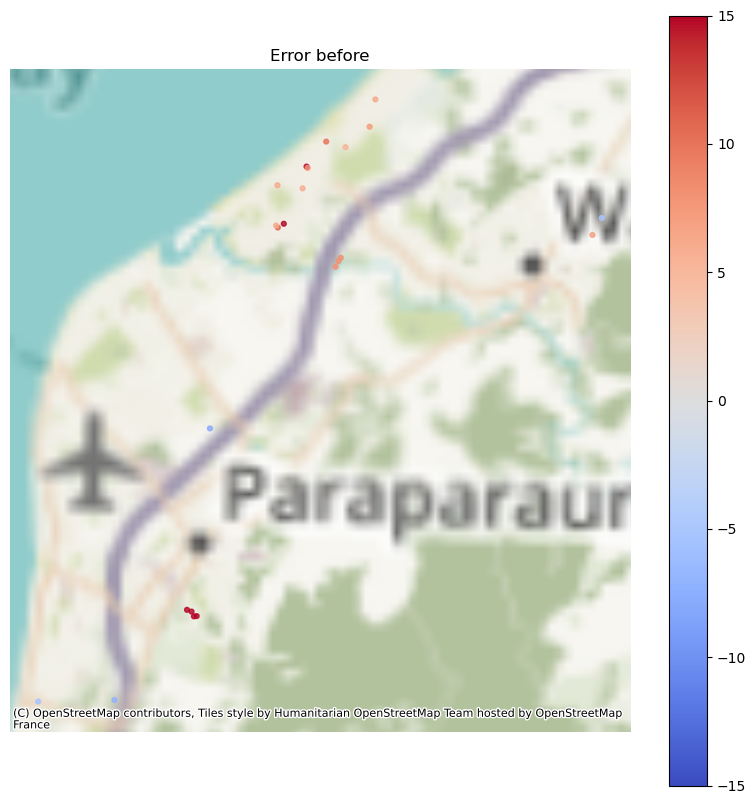

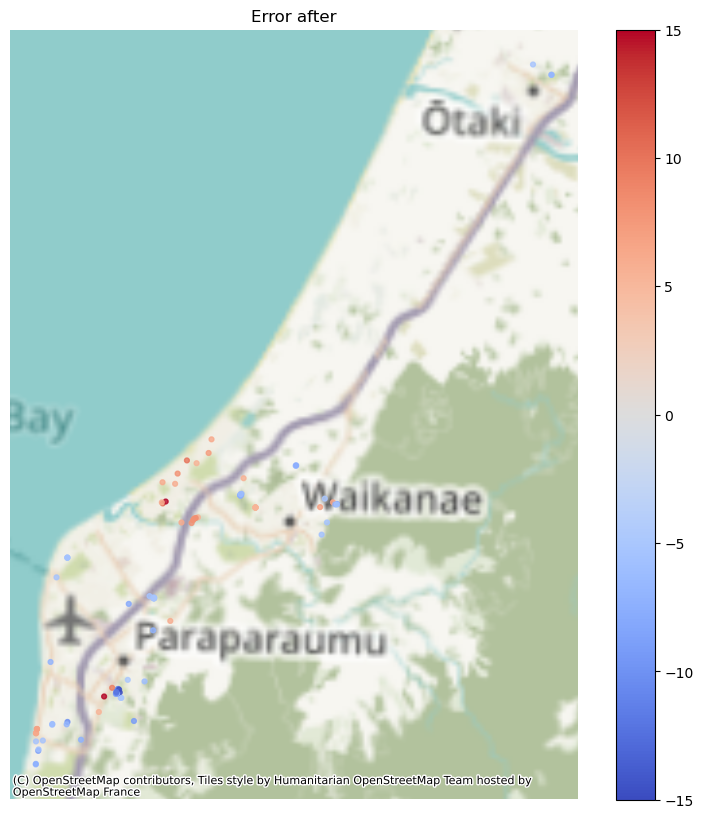

In [13]:
# ── Map: reconstruction error before / after correction ────────────────────
# Only nodes with an absolute error greater than 5 m are shown, to highlight
# where the largest discrepancies with the LiDAR reference are located.
norm = mcolors.TwoSlopeNorm(vmin=-15, vcenter=0, vmax=15)

mask = abs(gdf_before["err"]) > 5
test_before = gdf_before.loc[mask]

mask = abs(gdf_after["err"]) > 5
test_after = gdf_after.loc[mask]

ax = test_before.plot(
    column="err",
    cmap="coolwarm",
    norm=norm,
    legend=True,
    figsize=(10, 10),
    markersize=12,
    alpha=0.8
)
ctx.add_basemap(ax, crs=test_before.crs, zoom=10)
ax.set_title("Error before")
ax.set_axis_off()
plt.show()

ax = test_after.plot(
    column="err",
    cmap="coolwarm",
    norm=norm,
    legend=True,
    figsize=(10, 10),
    markersize=12,
    alpha=0.8
)
ctx.add_basemap(ax, crs=test_before.crs, zoom=10)
ax.set_title("Error after")
ax.set_axis_off()
plt.show()

Improved : 5
Degraded  : 0


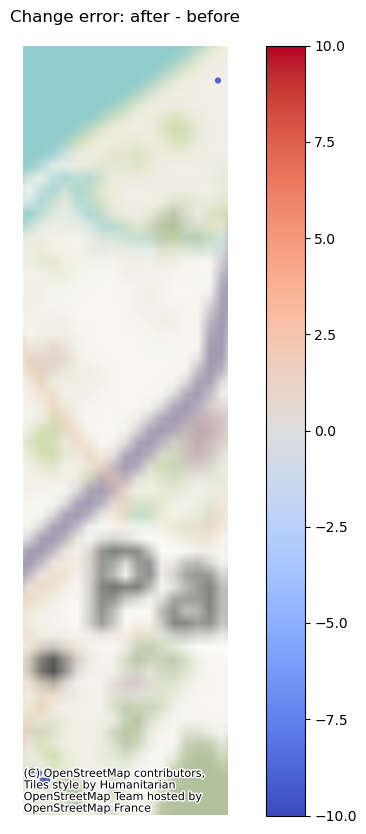

In [14]:
# ── Map: change in absolute error (after - before) ─────────────────────────
# Negative delta = the correction improved the point; positive = degraded it.
common_ids = set(gdf_before["node_id"]).intersection(set(gdf_after["node_id"]))

b = gdf_before[gdf_before["node_id"].isin(common_ids)].copy()
a = gdf_after[gdf_after["node_id"].isin(common_ids)].copy()

cmp = b[["node_id", "geometry", "err"]].merge(
    a[["node_id", "err"]],
    on="node_id",
    suffixes=("_before", "_after")
)

cmp["delta_abs_err"] = cmp["err_after"].abs() - cmp["err_before"].abs()

cmp = gpd.GeoDataFrame(cmp, geometry="geometry", crs=b.crs)

norm = mcolors.TwoSlopeNorm(vmin=-10, vcenter=0, vmax=10)

print("Improved :", (cmp["delta_abs_err"] < 0).sum())
print("Degraded  :", (cmp["delta_abs_err"] > 0).sum())

mask = cmp["delta_abs_err"] != 0
cmp = cmp.loc[mask]

ax = cmp.plot(
    column="delta_abs_err",
    cmap="coolwarm",
    norm=norm,
    legend=True,
    figsize=(10, 10),
    markersize=12,
    alpha=0.8
)

ctx.add_basemap(ax, crs=cmp.crs, zoom = 10)
ax.set_title("Change error: after - before")
ax.set_axis_off()
plt.show()

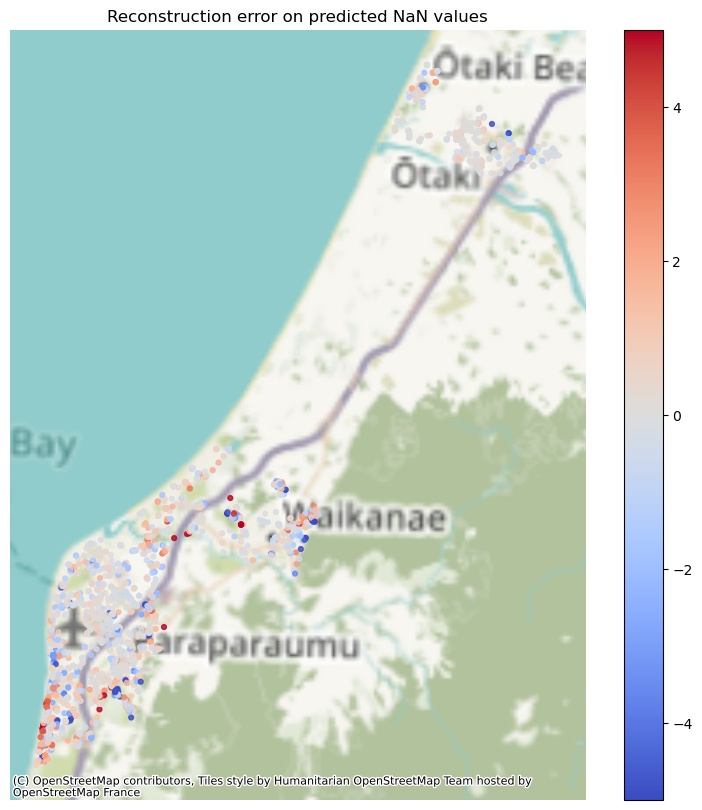

In [15]:
# ── Map: reconstruction error on the predicted (formerly missing) values ───
norm = mcolors.TwoSlopeNorm(vmin=-5, vcenter=0, vmax=5)

ax = predNaN.plot(
    column="err",
    cmap="coolwarm",
    norm=norm,
    legend=True,
    figsize=(10, 10),
    markersize=12,
    alpha=0.8
)
ctx.add_basemap(ax, crs=predNaN.crs, zoom = 10)
ax.set_title("Reconstruction error on predicted NaN values")
ax.set_axis_off()
plt.show()

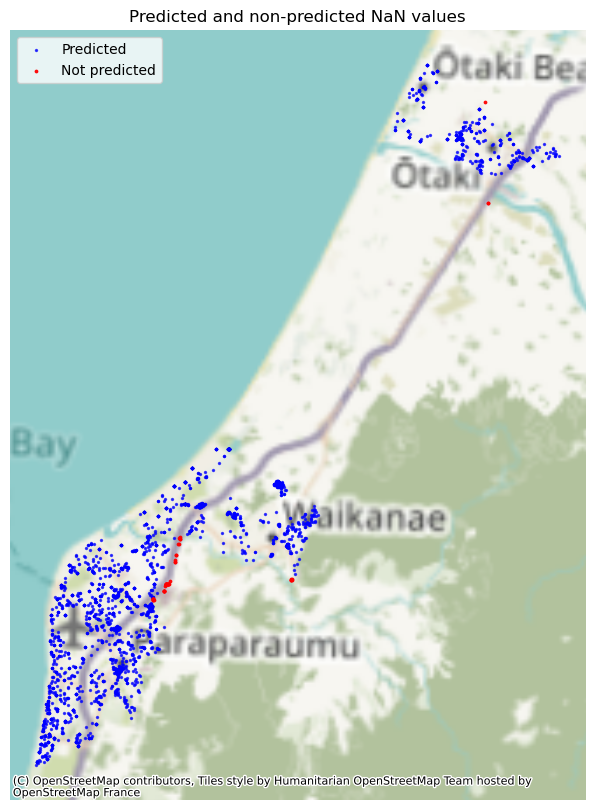

In [16]:
# ── Map: predicted vs. non-predicted missing (NaN) nodes ───────────────────
# Nodes that could not be reconstructed (too few valid neighbours within the
# search radius) are shown in red.
X_gdf = gpd.GeoDataFrame(X.copy(), geometry=gpd.points_from_xy(X["x"], X["y"]), crs=epsg)

nan_corriges = X_gdf[X_gdf["NaN_corrected"] == 1].copy()
nan_non_corr = X_gdf[X_gdf["NaN"] == 1].copy()

fig, ax = plt.subplots(figsize=(10, 10))

nan_corriges.plot(
    ax=ax,
    color="blue",
    markersize=2,
    alpha=0.7,
    label="Predicted"
)

nan_non_corr.plot(
    ax=ax,
    color="red",
    markersize=3,
    alpha=0.9,
    label="Not predicted"
)

ctx.add_basemap(ax, crs=X_gdf.crs, zoom = 10)

ax.set_title("Predicted and non-predicted NaN values")
ax.legend()
ax.set_axis_off()
plt.show()

In [17]:
# ─── Merge the reconstructed rim elevation back into the tables ────────────
# df_elev/X share df_node's row order (no filtering happens in between), so
# the reconstructed rim elevation can be written straight back by position;
# the assertion guards that alignment assumption. df_pipe carries the same
# value on its endpoint nodes via a many-to-one merge (a node feeds several
# pipes), then the endpoint depths are recomputed.

# ─── 1. Alignment guard ────────────────────────────────────────────────────
assert X["node_id"].equals(df_node["node_id"]), "X and df_node have diverged — row alignment assumption broken"

# ─── 2. Update df_node ──────────────────────────────────────────────────
df_node["rimElevation"] = X["rimElevation"]

if network == "Montpellier":
    # ─── 3. Update df_pipe (initRimElevation) ──────────────────────────────
    df_pipe = df_pipe.merge(
        df_node[["node_id", "rimElevation"]].rename(
            columns={"node_id": "initial_node", "rimElevation": "init_rim_new"}),
        on="initial_node",
        how="left"
    )
    df_pipe["initRimElevation"] = df_pipe["init_rim_new"].combine_first(df_pipe["initRimElevation"])
    df_pipe = df_pipe.drop(columns=["init_rim_new"])
    
    # ─── 4. Update df_pipe (terminalRimElevation) ──────────────────────────
    df_pipe = df_pipe.merge(
        df_node[["node_id", "rimElevation"]].rename(
            columns={"node_id": "terminal_node", "rimElevation": "term_rim_new"}),
        on="terminal_node",
        how="left"
    )
    df_pipe["terminalRimElevation"] = df_pipe["term_rim_new"].combine_first(df_pipe["terminalRimElevation"])
    df_pipe = df_pipe.drop(columns=["term_rim_new"])
    
    # ─── 5. Compute the derived depth variables ──────────────────────────
    df_pipe["initDepth"] = df_pipe["initRimElevation"] - df_pipe["initInvertElevation"]
    df_pipe["terminalDepth"] = df_pipe["terminalRimElevation"] - df_pipe["terminalInvertElevation"]
    
df_node["depth"] = df_node["rimElevation"] - df_node["invertElevation"]

In [56]:
# ── Serialisation ───────────────────────────────────────────────────────
# Save the updated pipe and node tables (rim elevation corrected/completed)
# for the downstream invert-elevation reconstruction notebook.
df_pipe.to_pickle(f"../data/{network}/df_pipe_{network}_rim.pkl")
df_node.to_pickle(f"../data/{network}/df_node_{network}_rim.pkl")